# Semaine 2 — Nettoyage, reconstruction de l'occupation & features

**Objectif :** passer des événements bruts (1 ligne = 1 stationnement) à une **table `features + target`** : le taux d'occupation par **rue** et par **tranche de 30 min**, avec les variables temporelles pour le ML.

**Done quand :** on a une table `X (features) + y (target)` exploitable, sauvegardée en parquet.

> Prototype sur un **sous-ensemble de rues** chargées à 100 % (pour ne pas saturer la RAM). On généralisera aux 123 rues en semaine 4 (industrialisation).

In [4]:
import re
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from parking.config import AGG_FREQ_MINUTES, DATA_PROCESSED, DATA_RAW

ZIP_PATH = DATA_RAW / "on-street-parking-2019.zip"
DATE_FMT = "%m/%d/%Y %I:%M:%S %p"
USECOLS = ["StreetName", "StreetMarker", "ArrivalTime", "DepartureTime"]


def find_csv_member(zf: zipfile.ZipFile) -> str:
    return next(
        n
        for n in zf.namelist()
        if n.lower().endswith(".csv") and not n.split("/")[-1].startswith("._")
    )


def to_snake(name: str) -> str:
    s = re.sub(r"(?<!^)(?=[A-Z])", "_", name.strip())
    return re.sub(r"[\s\-]+", "_", s).lower()


print("Granularité d'agrégation :", AGG_FREQ_MINUTES, "min")

Granularité d'agrégation : 30 min


## 1. Choisir un sous-ensemble de rues représentatif

On passe une fois sur un échantillon (5 %) pour mesurer la taille des rues (nombre de places), puis on retient ~8 rues de taille moyenne (20 à 80 places) — assez de places pour une agrégation fiable, sans charger les rues géantes.

In [5]:
parts = []
with zipfile.ZipFile(ZIP_PATH) as zf, zf.open(find_csv_member(zf)) as f:
    for i, c in enumerate(pd.read_csv(f, usecols=USECOLS, chunksize=500_000, low_memory=False)):
        parts.append(c.sample(frac=0.05, random_state=42 + i))
sample = pd.concat(parts, ignore_index=True)
sample.columns = [to_snake(x) for x in sample.columns]

bays = sample.groupby("street_name")["street_marker"].nunique()
mid = bays[(bays >= 20) & (bays <= 80)].sort_values()
idx = np.linspace(0, len(mid) - 1, 8).astype(int)
STREETS = list(mid.index[idx])
print("Rues retenues (places approx) :")
for s in STREETS:
    print(f"  {s:30} ~{int(bays[s])} places")

Rues retenues (places approx) :
  WELLS STREET                   ~20 places
  BATMAN STREET                  ~23 places
  SPENCER STREET                 ~28 places
  BATMANS HILL DRIVE             ~33 places
  DORCAS STREET                  ~36 places
  HARBOUR ESPLANADE              ~47 places
  ROYAL PARADE                   ~52 places
  CHETWYND STREET                ~72 places


## 2. Charger 100 % des données de ces rues

Cette fois on lit tout le fichier par chunks, mais on ne **garde** que les lignes des rues choisies.

In [3]:
keep = []
with zipfile.ZipFile(ZIP_PATH) as zf, zf.open(find_csv_member(zf)) as f:
    for c in pd.read_csv(f, usecols=USECOLS, chunksize=1_000_000, low_memory=False):
        c.columns = [to_snake(x) for x in c.columns]
        keep.append(c[c["street_name"].isin(STREETS)])

df = pd.concat(keep, ignore_index=True)
df["arrival_time"] = pd.to_datetime(df["arrival_time"], format=DATE_FMT, errors="coerce")
df["departure_time"] = pd.to_datetime(df["departure_time"], format=DATE_FMT, errors="coerce")
print(f"{len(df):,} stationnements chargés pour {df['street_name'].nunique()} rues")
df.head()

2,360,532 stationnements chargés pour 8 rues


,arrival_time,departure_time,street_marker,street_name
0,2019-11-02 16:29:22,2019-11-02 16:38:00,13345W,BATMANS HILL DRIVE
1,2019-06-05 17:43:14,2019-06-05 18:30:00,14072E,ROYAL PARADE
2,2019-08-07 18:55:33,2019-08-07 18:56:06,1549W,SPENCER STREET
3,2019-03-22 07:30:00,2019-03-22 10:19:08,13446E,BATMANS HILL DRIVE
4,2019-07-06 23:13:30,2019-07-06 23:14:08,13342E,HARBOUR ESPLANADE


## 3. Nettoyage

On a vu en semaine 1 les défauts : durées ≤ 0 (capteurs qui clignotent) et durées aberrantes (départs manquants → intervalles de plusieurs jours). On calcule la durée, on inspecte, puis on filtre.

In [6]:
n0 = len(df)
df = df.dropna(subset=["arrival_time", "departure_time", "street_marker"])
df["duration_min"] = (df["departure_time"] - df["arrival_time"]).dt.total_seconds() / 60

print("Distribution des durées (min) AVANT nettoyage :")
print(df["duration_min"].describe(percentiles=[0.5, 0.9, 0.99]).round(1))
print(f"\nDurées <= 0 : {(df['duration_min'] <= 0).sum():,}")
print(f"Durées > 12h (départ manquant probable) : {(df['duration_min'] > 720).sum():,}")

# Filtre : durée strictement positive et <= 12h
df = df[(df["duration_min"] > 0) & (df["duration_min"] <= 720)].copy()
print(f"\nLignes conservées : {len(df):,} / {n0:,} ({len(df) / n0:.1%})")

Distribution des durées (min) AVANT nettoyage :
count    2360532.0
mean          62.7
std          117.7
min        -1255.2
50%           12.9
90%          196.9
99%          491.5
max         1440.0
Name: duration_min, dtype: float64

Durées <= 0 : 1,771
Durées > 12h (départ manquant probable) : 3,750

Lignes conservées : 2,355,011 / 2,360,532 (99.8%)


## 4. Reconstruire le taux d'occupation par rue et par tranche de 30 min

Pour une rue, à un instant `t`, le nombre de places occupées = nombre d'intervalles [arrivée, départ] actifs à `t`. On l'évalue sur une grille de 30 min, puis :

$$\text{taux occupation} = \frac{\text{places occupées}}{\text{nombre de places de la rue}}$$

> Les chevauchements sur une même place sont négligeables (~0,1 %, vu en semaine 1), donc on compte directement les intervalles actifs et on plafonne le taux à 100 %.

In [7]:
FREQ = f"{AGG_FREQ_MINUTES}min"


def occupancy_for_street(d: pd.DataFrame) -> pd.DataFrame:
    """Taux d'occupation d'une rue sur une grille de 30 min."""
    n_bays = d["street_marker"].nunique()
    # Grille bornée à la période réellement couverte par les capteurs de la rue
    start = d["arrival_time"].min().floor(FREQ)
    end = d["departure_time"].max().ceil(FREQ)
    grid = pd.date_range(start, end, freq=FREQ)
    gt = grid.values.astype("datetime64[ns]")
    arr = np.sort(d["arrival_time"].values)
    dep = np.sort(d["departure_time"].values)
    occupied = np.searchsorted(arr, gt, side="right") - np.searchsorted(dep, gt, side="right")
    rate = np.clip(occupied / n_bays, 0, 1)
    return pd.DataFrame({"slot": grid, "occupancy_rate": rate, "n_bays": n_bays})


frames = []
for street, d in df.groupby("street_name"):
    occ = occupancy_for_street(d)
    occ["street_name"] = street
    frames.append(occ)
occ_df = pd.concat(frames, ignore_index=True)
print(f"Table d'occupation : {len(occ_df):,} lignes (rue × tranche de 30 min)")
occ_df.head()

Table d'occupation : 140,163 lignes (rue × tranche de 30 min)


,slot,occupancy_rate,n_bays,street_name
0,2019-01-01 00:00:00,0.956522,23,BATMAN STREET
1,2019-01-01 00:30:00,0.956522,23,BATMAN STREET
2,2019-01-01 01:00:00,0.956522,23,BATMAN STREET
3,2019-01-01 01:30:00,0.956522,23,BATMAN STREET
4,2019-01-01 02:00:00,0.956522,23,BATMAN STREET


## 5. Features + cible

On dérive les variables temporelles depuis `slot`. La **cible** est le taux d'occupation ; on ajoute aussi `free_rate = 1 - occupation` (plus proche de « probabilité de trouver une place »).

In [8]:
occ_df["hour"] = occ_df["slot"].dt.hour
occ_df["minute"] = occ_df["slot"].dt.minute
occ_df["day_of_week"] = occ_df["slot"].dt.dayofweek  # 0 = lundi
occ_df["is_weekend"] = (occ_df["day_of_week"] >= 5).astype(int)
occ_df["month"] = occ_df["slot"].dt.month
occ_df["free_rate"] = 1 - occ_df["occupancy_rate"]

feature_cols = ["street_name", "hour", "minute", "day_of_week", "is_weekend", "month"]
print("Features :", feature_cols)
print("Cible : occupancy_rate (et free_rate)")
occ_df[[*feature_cols, "occupancy_rate", "free_rate"]].head()

Features : ['street_name', 'hour', 'minute', 'day_of_week', 'is_weekend', 'month']
Cible : occupancy_rate (et free_rate)


,street_name,hour,minute,day_of_week,is_weekend,month,occupancy_rate,free_rate
0,BATMAN STREET,0,0,1,0,1,0.956522,0.043478
1,BATMAN STREET,0,30,1,0,1,0.956522,0.043478
2,BATMAN STREET,1,0,1,0,1,0.956522,0.043478
3,BATMAN STREET,1,30,1,0,1,0.956522,0.043478
4,BATMAN STREET,2,0,1,0,1,0.956522,0.043478


## 6. EDA : les patterns ressortent-ils ?

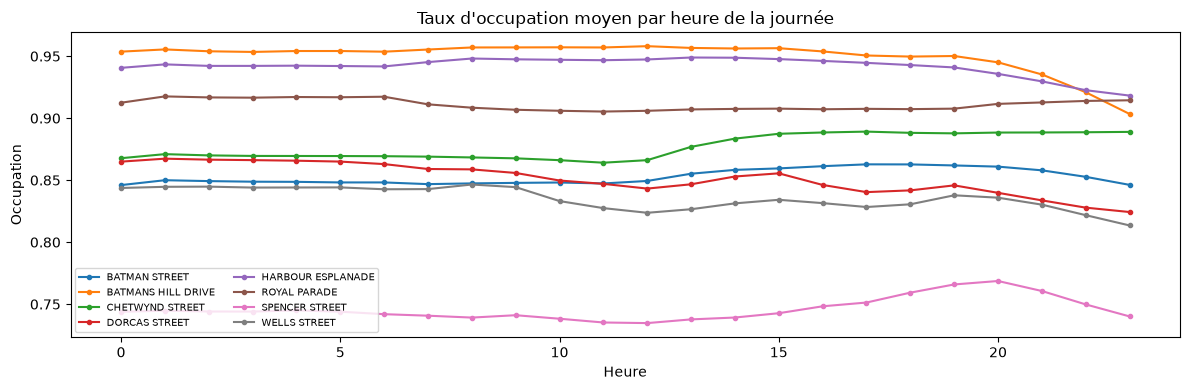

In [9]:
# Occupation moyenne par heure, pour chaque rue
fig, ax = plt.subplots(figsize=(12, 4))
for street, g in occ_df.groupby("street_name"):
    g.groupby("hour")["occupancy_rate"].mean().plot(ax=ax, label=street[:18], marker=".")
ax.set_title("Taux d'occupation moyen par heure de la journée")
ax.set_xlabel("Heure")
ax.set_ylabel("Occupation")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

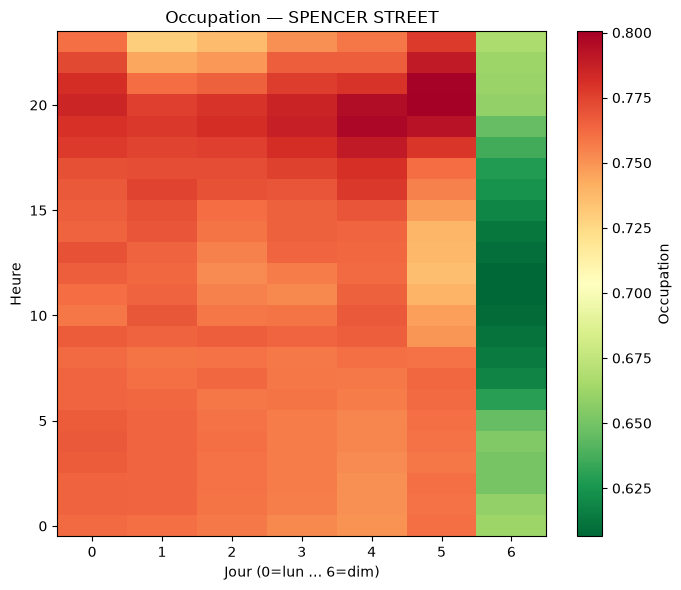

In [10]:
# Heatmap heure × jour de semaine pour la rue la plus fournie
top_street = df["street_name"].value_counts().index[0]
pivot = occ_df[occ_df["street_name"] == top_street].pivot_table(
    index="hour", columns="day_of_week", values="occupancy_rate", aggfunc="mean"
)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(pivot, aspect="auto", origin="lower", cmap="RdYlGn_r")
ax.set_title(f"Occupation — {top_street}")
ax.set_xlabel("Jour (0=lun … 6=dim)")
ax.set_ylabel("Heure")
fig.colorbar(im, ax=ax, label="Occupation")
plt.tight_layout()
plt.show()

## 7. Sauvegarde de la table features + target

In [11]:
out = DATA_PROCESSED / "occupancy_features_2019_subset.parquet"
cols = [*feature_cols, "slot", "n_bays", "occupancy_rate", "free_rate"]
occ_df[cols].to_parquet(out, index=False)
print(f"Sauvegardé : {out}")
print(f"{len(occ_df):,} lignes × {len(cols)} colonnes")

Sauvegardé : /Users/bilalfym/Parking_project/data/processed/occupancy_features_2019_subset.parquet
140,163 lignes × 10 colonnes


## 8. Conclusions

**Nettoyage**
- **2 360 532** stationnements bruts (8 rues) → **2 355 011 conservés (99,8 %)**.
- Retirés : **1 771** durées ≤ 0 (capteurs qui clignotent) + **3 750** durées > 12h (départs manquants).
- Durée de stationnement : médiane **12,9 min**, moyenne 62,7 min (distribution très asymétrique).

**Table finale (features + target)**
- **140 163 lignes** = 8 rues × ~17 520 créneaux de 30 min (année 2019 complète).
- Features : `street_name`, `hour`, `minute`, `day_of_week`, `is_weekend`, `month`. Cible : `occupancy_rate` (et `free_rate`). 0 valeur manquante.

**Patterns observés**
- Occupation **élevée partout** : moyenne **0,87**, de 0,75 (Spencer St) à 0,95 (Batmans Hill Dr).
- Variation heure/jour **modérée** (confirme la semaine 1) : ces rues restent bien remplies, y compris la nuit.
- Spencer St (la moins occupée) est la plus « intéressante » pour trouver une place.

**Prochaine étape (semaine 3)** : **baseline naïve** (moyenne historique par rue × heure × jour de semaine), puis premier modèle (Random Forest / XGBoost) évalué *contre* la baseline (MAE en régression). Vu l'occupation très stable, l'enjeu sera de voir si le modèle apporte un gain réel sur cette baseline.

Le code stabilisé ici sera remonté dans `parking.features` en semaine 4 et généralisé aux 123 rues.